In [184]:
from matplotlib import pyplot as plt
import numpy as np
import scipy as sp
import IPython.display
from IPython.display import Markdown
from IPython.display import Image, SVG
import pandas as pd

# Reliability Calculator Distributed System Mission

This code is the one to be run. This is the file where the inputs are set and the iterations run
based on the user's desire. The inputs define the parameters of the DSM and simulation, as well as
outputing the reliability graphs. This file uses the functions set on Reliability.py.

#### Other Variables
They start blank at the beginning of each iteration. 
- iteration: string that asks whether the user wants to try another DSM configuration
- graph_labels: array that compiles the configuration parameters entered to be lated used as the graph's label.
- cont: variable used in the iteration of a final graph.
- year_to_month: a conversion, self explained.


In [185]:
R_simulation = []
iteration = ''
graph_labels = []
year_to_month = 12

## Inputs

### Mission Time
This input sets how much time does the distributed mission lasts, in years. This provides the timeframe for the simulation to work.

In [186]:
Mission_time = 8
Time_months = np.arange(0, Mission_time * year_to_month)

First batch of satellites launched

In [187]:
DSM_initial_amount = [7, 5, 2 , 2, 2]

### CubeSat Reliability Curve
INPUTS for subsystems in the following collumn sequence ADCS; CDHS; COMMS; STS&DepS and P/L; EPS

In [188]:
mu = [15.4, 11.5, 13.7, 14.3, 14.3, 9.4]    #Log-normal \mu
sigma = [10, 8.39, 9.79, 9.21, 9.21, 8.18]  #Log-normal \sigma_1
theta = [2.6, 8.1, 2.6, 2.7, 2.7, 2.9]      #Gomperts \theta
nu = [9.1e-5, 0.0167, 8.3e-5, 0.00011, 0.00011, 0.00011]    #Gompertz \nu

In [189]:
def Reliability_CubeSat(EPS_redundancy, Time_months): # Subsystem level realibility inputs Source: Bouwmeester et al 2022 - Fig 11
    R_CubeSat = 1
#Subsystem redundancy true is redundant (red) and false (off) is no subsystem redundancy
    #Only analisis case for EPS redundancy, due to its lower reliability over time
    counter: int # counter is a variable used for the loop as counter
    for counter in np.arange(len(mu)):
        if EPS_redundancy and counter == 5:  #Counter ==5 is the position in the input vector for EPS reliability
            R_CubeSat *= 1 - np.square(
                1 - sp.stats.lognorm.sf(Time_months, sigma[counter], scale=np.exp(mu[counter])) * sp.stats.gompertz.sf(Time_months, nu[
                    counter] / theta[counter], scale=theta[counter]))
        else: #No redundancy
            R_CubeSat *= sp.stats.lognorm.sf(Time_months, sigma[counter], scale=np.exp(mu[counter])) * sp.stats.gompertz.sf(Time_months, nu[
                counter] / theta[counter], scale=theta[counter])
    return R_CubeSat #outputs the system level reliability curve

## Process

### Mission Strategy

#### Subsystem Redundancy
Explain here ----
- EPS_redundancy: Boolean variable, defines the existence or absence in redundancy in EPS subsystem.

In [190]:
EPS_redundancy = [False, False, False, True, False]

#### Phased Deployment
Explain here----
- Phase_Deployment: Boolean variable, defines the use of phased deployment as mission strategy.
- relaunch_rate: Amount of months between launches of new batches to the DSM
- DSM_relaunch_amount: Amount of satellites to be thrown per relaunch. 

In [191]:
Phase_Deployment = [True, True, True, True, False]
relaunch_rate = [24, 12, 30, 24, 0]
DSM_relaunch_amount = [1, 2, 1, 1, 0]

---- Explain here the code written --- Remove the prints and use display markdown ---

In [192]:
simulation_results = []
for iteration in np.arange(len(DSM_initial_amount)):
    R_DSM_3m = 0
    R_DSM_6m = 0
    R_DSM_12m = 0
    R_DSM_18m = 0
    if Phase_Deployment[iteration] == True:
        R_DSM = []
        for Current_Time in Time_months:
            R_elem = np.ones(DSM_initial_amount[iteration]) * Reliability_CubeSat(EPS_redundancy[iteration], Current_Time / year_to_month)
            Deployment_Dates = np.arange(relaunch_rate[iteration], (Mission_time * year_to_month) + 1, relaunch_rate[iteration], dtype=int) # Array that gives the dates for phased deployment, in months

            for a in Deployment_Dates: # if the current time is over the deployment date, it adds new elements to the DSM, else continues
                if int(Current_Time) >= int(a):
                    R_elem = np.append(R_elem, np.ones(DSM_relaunch_amount[iteration]) * Reliability_CubeSat(EPS_redundancy[iteration], Current_Time / year_to_month - float(a / year_to_month))).tolist()
                else:
                    continue #sets DSM size and cubesats reliabilities, updating it to the current time
            
            R_DSM_partial = 1
            for R_CubeSat in np.arange(len(R_elem)):
                R_DSM_partial *= 1 - R_elem[R_CubeSat]
            R_DSM.append(1 - R_DSM_partial)
            if Current_Time == 3:
                R_DSM_3m = np.round(1 - R_DSM_partial, 3)
            elif Current_Time == 6:
                R_DSM_6m = np.round(1 - R_DSM_partial, 3)
            elif Current_Time == 12:
                R_DSM_12m = np.round(1 - R_DSM_partial, 3)
            elif Current_Time == 18:
                R_DSM_18m = np.round(1 - R_DSM_partial, 3) #gets DSM reliability and appends on the array
    else:
        R_DSM = []
        for Current_Time in Time_months:
            R_elem = np.ones(DSM_initial_amount[iteration]) * Reliability_CubeSat(EPS_redundancy[iteration], Current_Time  / year_to_month) #sets DSM size and cubesats reliabilities
            
            R_DSM_partial = 1
            for R_CubeSat in np.arange(len(R_elem)):
                R_DSM_partial *= 1 - R_elem[R_CubeSat]
            R_DSM.append(1 - R_DSM_partial) #gets DSM reliability and appends on the array
            relaunch_rate[iteration] = 0
            DSM_relaunch_amount[iteration] = 0
            if Current_Time == 3:
                R_DSM_3m = np.round(1 - R_DSM_partial, 3)
            elif Current_Time == 6:
                R_DSM_6m = np.round(1 - R_DSM_partial, 3)
            elif Current_Time == 12:
                R_DSM_12m = np.round(1 - R_DSM_partial, 3)
            elif Current_Time == 18:
                R_DSM_18m = np.round(1 - R_DSM_partial, 3)
    
    result = {'Scenario': iteration + 1, 'Initial Batch': DSM_initial_amount[iteration], 'Subsystem Redundancy': str(EPS_redundancy[iteration]), 'Relaunch Rate': relaunch_rate[iteration], 'Reliability at 3 months': R_DSM_3m, 'Reliability at 6 months': R_DSM_6m, 'Reliability at 12 months': R_DSM_12m, 'Reliability at 18 months': R_DSM_18m}
    simulation_results.append(result)
    R_simulation.append(R_DSM)
    graph_labels.append('EPS_redundancy: ' + str(EPS_redundancy[iteration]) + ', initial: ' + str(DSM_initial_amount[iteration]) + ', relaunch: ' + str(DSM_relaunch_amount[iteration]) + ', rate: ' + str(relaunch_rate[iteration]))
df = pd.DataFrame(simulation_results)
    


## Outputs
The output of this program provides both a comparison table of all case scenarios, the reliability of their systems at certain months in time and a graphic that compares the curve of each of them.

In [193]:
markdown_table = df.to_markdown()
Markdown(markdown_table)

|    |   Scenario |   Initial Batch | Subsystem Redundancy   |   Relaunch Rate |   Reliability at 3 months |   Reliability at 6 months |   Reliability at 12 months |   Reliability at 18 months |
|---:|-----------:|----------------:|:-----------------------|----------------:|--------------------------:|--------------------------:|---------------------------:|---------------------------:|
|  0 |          1 |               7 | False                  |              24 |                     1     |                     0.999 |                      0.999 |                      0.998 |
|  1 |          2 |               5 | False                  |              12 |                     0.997 |                     0.995 |                      1     |                      0.998 |
|  2 |          3 |               2 | False                  |              30 |                     0.907 |                     0.88  |                      0.847 |                      0.826 |
|  3 |          4 |               2 | True                   |              24 |                     0.942 |                     0.924 |                      0.901 |                      0.885 |
|  4 |          5 |               2 | False                  |               0 |                     0.907 |                     0.88  |                      0.847 |                      0.826 |

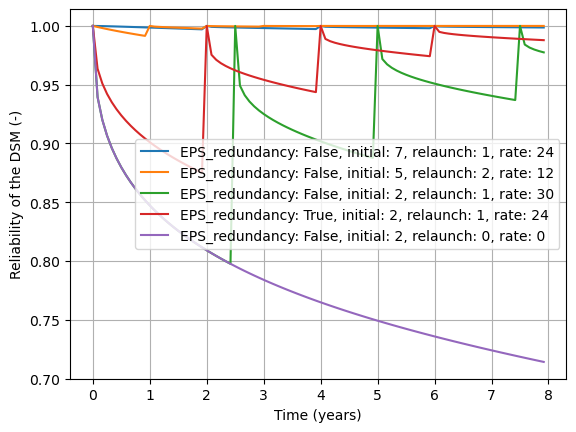

In [194]:
plt.figure(1)

for cont in range(len(R_simulation)):
    plt.plot(Time_months / 12, R_simulation[cont], label=graph_labels[cont])

plt.xlabel('Time (years)')
plt.ylabel('Reliability of the DSM (-)')
plt.legend()
plt.grid(True)
plt.show()